# TEMP one-off: audit & fix mislabeled reward records

Session `E:\D1-1-6_IM-1979\behavior\2026-09-07`. The reward pump had an intermittent
circuit fault: on some trials the arduino logged `rwd delivered` but no water actually
came out. Tell-tale sign: with no real reward the mouse leaves the port much sooner, so
the IR beam-breaker at that port stays broken for a much shorter time.

This notebook:
1. parses `arduinoraw0.txt` (parsing mirrors `jdb_to_nwb.convert_behavior.parse_arduino_text`),
2. computes the beam-break dwell time for every reward-outcome event,
3. shows a table + plots so the bad trials can be picked out by eye,
4. lists the suspect trials (rewarded but short dwell) with the matching time span in
   `Behav_Vid0.avi` + a ready-to-run `ffmpeg` clip command, so the pump can be checked
   on video,
5. rewrites only the outcome lines listed in a hand-written `reward_corrections.txt`
   into a new file `arduinoraw0_corrected.txt` (line count preserved, so
   `ArduinoStamps0.csv` stays aligned; the raw files are untouched).

Throwaway analysis, not part of the OptoNPX pipeline — hence the `tmp_` prefix.

In [1]:
from pathlib import Path

# ======== parameters ========
behavior_dir   = Path(r"E:/D1-1-6_IM-1979/behavior/2026-09-07")
arduino_txt    = behavior_dir / "arduinoraw0.txt"
arduino_stamps = behavior_dir / "ArduinoStamps0.csv"    # authoritative per-line timestamps (ms since local midnight)
poke_end_gap_s = 1.0                                    # beam-break run ends on a gap >= this (same as jdb_to_nwb)

# --- behavior video (for eyeballing the peristaltic pump on suspect trials) ---
video_timestamps    = behavior_dir / "testvidtimes0.csv"   # 1 row per frame, SAME clock as arduino_stamps
video_file          = behavior_dir / "Behav_Vid0.avi"      # frame i  <->  testvidtimes0.csv row i
video_container_fps = 30.0                                 # the .avi header rate; a player seeks by frame_index / this
                                                          # (real capture was ~14.5 fps; only the csv has true timing)
dwell_threshold_s   = 2.0                                  # a `rwd delivered` outcome with dwell < this is "suspect"
clip_pad_s          = 5.0                                  # seconds kept before poke-in / after poke-out for the review clip
ffmpeg_exe          = r"C:/Users/Jeff/miniforge3/envs/dlc/Library/bin/ffmpeg.exe"  # not in optonpx; present in the dlc env

# --- outputs (all NEW files; raw arduinoraw0.txt / ArduinoStamps0.csv are never modified) ---
audit_csv        = behavior_dir / "reward_dwell_audit.csv"
suspects_csv     = behavior_dir / "suspect_trials_video_clips.csv"
corrections_file = behavior_dir / "reward_corrections.txt"           # hand-written by the user (see the last cell)
corrections_tmpl = behavior_dir / "reward_corrections.template.txt"  # auto-generated starting point
corrected_txt    = behavior_dir / "arduinoraw0_corrected.txt"        # the fixed log

trials_to_flip = []   # optional inline additions, merged with corrections_file (list of outcome_lineno ints)
# ============================

print(f"text   : {arduino_txt}")
print(f"stamps : {arduino_stamps}")
print(f"video  : {video_file}")

text   : E:\D1-1-6_IM-1979\behavior\2026-09-07\arduinoraw0.txt
stamps : E:\D1-1-6_IM-1979\behavior\2026-09-07\ArduinoStamps0.csv
video  : E:\D1-1-6_IM-1979\behavior\2026-09-07\Behav_Vid0.avi


In [2]:
import re
import numpy as np
import pandas as pd

# Regexes match jdb_to_nwb.convert_behavior (same line grammar).
BB_RE      = re.compile(r"beam break at port (\w); (\d+) trial (\d+) of (\d+)")
BLOCK_RE   = re.compile(r"Block: (\d+)")
RWD_RE     = re.compile(r"rwd delivered at port (\w); (\d+)")
NORWD_RE   = re.compile(r"no Reward port (\w); trial (\d+) of (\d+)")

text_lines = arduino_txt.read_text().splitlines()
ts_ms      = np.array([float(x) for x in arduino_stamps.read_text().split()], dtype=float)
assert len(text_lines) == len(ts_ms), (len(text_lines), len(ts_ms))
ts_s = ts_ms / 1000.0
N    = len(text_lines)
print(f"{N} lines")


def _run_bounds(port, j, gap_s):
    """Given outcome line index j (0-based), return (first, last) 0-based indices of the
    maximal beam-break-at-`port` run that the outcome belongs to. The run is the animal's
    poke at the destination port: poke-in is the first beam-break line, poke-out the last
    before a >= gap_s gap. The single outcome line at j is skipped when walking forward.
    """
    first = j - 1                       # arduino prints the outcome right after the 1st beam break
    while first - 1 >= 0:
        m = BB_RE.match(text_lines[first - 1])
        if m and m.group(1) == port and (ts_s[first] - ts_s[first - 1]) < gap_s:
            first -= 1
        else:
            break
    last = j - 1
    p = j + 1
    while p < N:
        m = BB_RE.match(text_lines[p])
        if m and m.group(1) == port and (ts_s[p] - ts_s[last]) < gap_s:
            last, p = p, p + 1
        else:
            break
    return first, last


def parse_reward_outcomes(gap_s=poke_end_gap_s):
    """One row per reward-outcome event (`rwd delivered` / `no Reward`), with the dwell
    time of the beam-break run it is attached to. Block context is tracked from the
    recurring `Block:` + `pA/pB/pC` header blocks.
    """
    rows = []
    block = pA = pB = pC = None
    n_in_block = 0
    for j, line in enumerate(text_lines):
        mb = BLOCK_RE.match(line)
        if mb:
            block = int(mb.group(1))
            pA = int(text_lines[j + 1].split(":")[1])
            pB = int(text_lines[j + 2].split(":")[1])
            pC = int(text_lines[j + 3].split(":")[1])
            n_in_block = 0
            continue

        mr, mn = RWD_RE.match(line), NORWD_RE.match(line)
        if not (mr or mn):
            continue
        rewarded = mr is not None
        port     = (mr or mn).group(1)

        poke_in_line = text_lines[j - 1]
        mbb = BB_RE.match(poke_in_line)
        if not mbb or mbb.group(1) != port:
            # outcome not immediately preceded by a beam break at the same port -> flag, skip dwell
            rows.append(dict(outcome_lineno=j + 1, block=block, port=port,
                             rewarded=int(rewarded), arduino_trial=np.nan, block_trial_total=np.nan,
                             poke_in_lineno=np.nan, poke_out_lineno=np.nan, n_bb_lines=0,
                             dwell_s=np.nan, dwell_ms_embedded=np.nan,
                             pA=pA, pB=pB, pC=pC, malformed=True))
            continue

        arduino_trial     = int(mbb.group(3))
        block_trial_total = int(mbb.group(4))
        first, last = _run_bounds(port, j, gap_s)
        n_bb = sum(1 for k in range(first, last + 1) if BB_RE.match(text_lines[k]))
        n_in_block += 1
        rows.append(dict(
            outcome_lineno=j + 1,
            block=block, block_outcome_idx=n_in_block,
            port=port, rewarded=int(rewarded),
            arduino_trial=arduino_trial, block_trial_total=block_trial_total,
            poke_in_lineno=first + 1, poke_out_lineno=last + 1, n_bb_lines=n_bb,
            dwell_s=float(ts_s[last] - ts_s[first]),
            dwell_ms_embedded=int(BB_RE.match(text_lines[last]).group(2))
                              - int(BB_RE.match(text_lines[first]).group(2)),
            pA=pA, pB=pB, pC=pC, malformed=False,
        ))
    df = pd.DataFrame(rows)
    df.insert(0, "outcome_seq", np.arange(1, len(df) + 1))
    return df


outcomes = parse_reward_outcomes()
print(f"{len(outcomes)} reward-outcome events "
      f"({int(outcomes.rewarded.sum())} rewarded, {int((1 - outcomes.rewarded).sum())} no-reward, "
      f"{int(outcomes.malformed.sum())} malformed)")
print(outcomes.groupby('block').size().rename('n_outcomes').to_string())

32149 lines
386 reward-outcome events (222 rewarded, 164 no-reward, 0 malformed)
block
0    62
1    60
2    69
3    61
4    67
5    67


In [3]:
# ---- full audit table -------------------------------------------------------
outcomes.to_csv(audit_csv, index=False)
print(f"wrote {audit_csv}")

print("\ndwell_s by outcome:")
print(outcomes.groupby(outcomes.rewarded.map({1: 'rewarded', 0: 'no-reward'}))['dwell_s']
      .describe()[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].to_string())

# HINT (not a decision): rewarded outcomes whose dwell sits inside the no-reward cloud.
# The next cell turns this into the actual suspect list (with a tunable threshold).
no_rwd_p90 = outcomes.loc[outcomes.rewarded == 0, 'dwell_s'].quantile(0.90)
hint_suspects = outcomes[(outcomes.rewarded == 1) & (outcomes.dwell_s <= no_rwd_p90)]
print(f"\n{len(hint_suspects)} rewarded outcomes with dwell_s <= no-reward 90th pctile ({no_rwd_p90:.2f}s) "
      f"-- candidates to inspect (confirm by eye / on video):")
print(hint_suspects[['outcome_seq', 'outcome_lineno', 'block', 'port', 'arduino_trial',
                     'dwell_s', 'n_bb_lines', 'poke_in_lineno', 'poke_out_lineno']].to_string(index=False))

with pd.option_context('display.max_rows', None, 'display.width', 200):
    display(outcomes[['outcome_seq', 'outcome_lineno', 'block', 'block_outcome_idx', 'port',
                      'rewarded', 'arduino_trial', 'block_trial_total', 'dwell_s',
                      'dwell_ms_embedded', 'n_bb_lines', 'poke_in_lineno', 'poke_out_lineno']])

wrote E:\D1-1-6_IM-1979\behavior\2026-09-07\reward_dwell_audit.csv

dwell_s by outcome:
           count      mean       std  min       25%       50%       75%        max
rewarded                                                                          
no-reward  164.0  0.890533  0.900938  0.0  0.552803  0.692256  0.996269  10.900186
rewarded   222.0  6.118340  2.097141  0.0  5.285142  6.287590  7.141693  13.177357

15 rewarded outcomes with dwell_s <= no-reward 90th pctile (1.53s) -- candidates to inspect (confirm by eye / on video):
 outcome_seq  outcome_lineno  block port  arduino_trial  dwell_s  n_bb_lines  poke_in_lineno  poke_out_lineno
         105            9304      1    A             42 0.725005          13            9303             9316
         108            9345      1    A             45 1.233114          24            9344             9368
         111            9533      1    A             48 0.634714          13            9532             9545
         118      

,outcome_seq,outcome_lineno,block,block_outcome_idx,port,rewarded,arduino_trial,block_trial_total,dwell_s,dwell_ms_embedded,n_bb_lines,poke_in_lineno,poke_out_lineno
0,1,9,0,1,C,0,0,62,1.556646,1510,35,8,43
1,2,45,0,2,B,1,1,62,7.471821,7416,161,44,205
2,3,207,0,3,C,1,2,62,7.058022,7003,152,206,358
3,4,360,0,4,A,0,3,62,10.900186,10838,238,359,597
4,5,599,0,5,B,1,4,62,6.213990,6159,130,598,728
5,6,730,0,6,C,0,5,62,2.097152,2049,46,729,775
6,7,777,0,7,A,1,6,62,8.999360,8940,192,776,968
7,8,970,0,8,B,1,7,62,4.735040,4681,103,969,1072
8,9,1074,0,9,C,0,8,62,1.683674,1637,37,1073,1110
9,10,1112,0,10,A,1,9,62,6.439232,6380,137,1111,1248


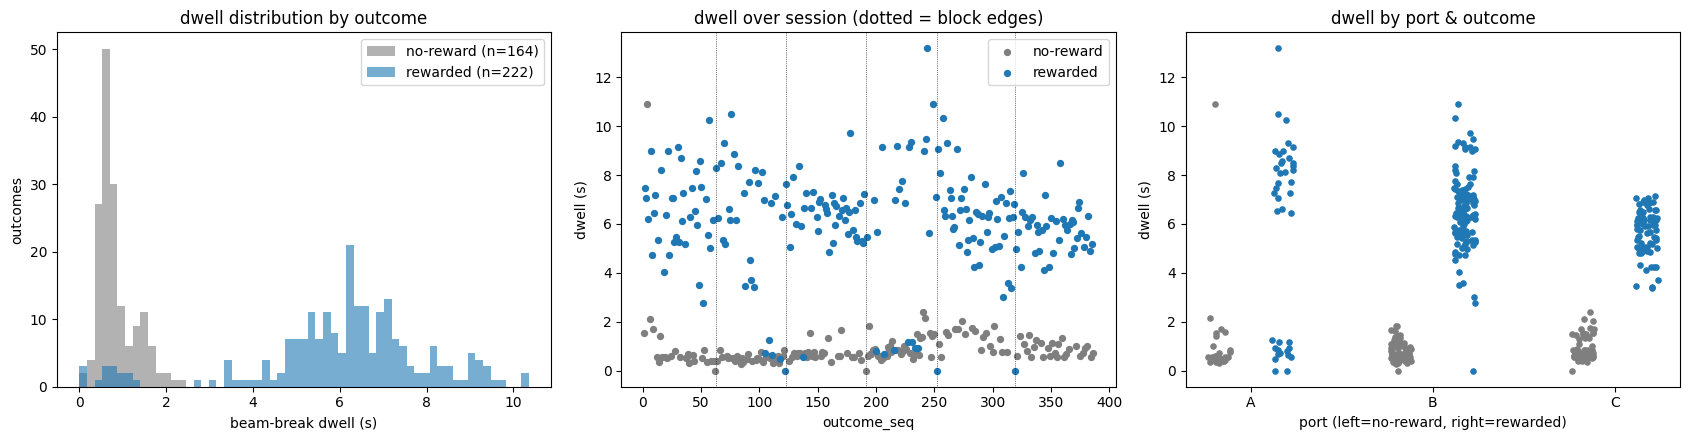

In [4]:
# ---- plots ----------------------------------------------------------------
import matplotlib.pyplot as plt

ok = outcomes[~outcomes.malformed]
rwd   = ok[ok.rewarded == 1]
norwd = ok[ok.rewarded == 0]

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

bins = np.linspace(0, np.nanpercentile(ok.dwell_s, 99), 60)
axes[0].hist(norwd.dwell_s, bins=bins, alpha=0.6, label=f'no-reward (n={len(norwd)})', color='tab:gray')
axes[0].hist(rwd.dwell_s,   bins=bins, alpha=0.6, label=f'rewarded (n={len(rwd)})',  color='tab:blue')
axes[0].set_xlabel('beam-break dwell (s)'); axes[0].set_ylabel('outcomes'); axes[0].legend()
axes[0].set_title('dwell distribution by outcome')

axes[1].scatter(norwd.outcome_seq, norwd.dwell_s, s=18, color='tab:gray', label='no-reward')
axes[1].scatter(rwd.outcome_seq,   rwd.dwell_s,   s=18, color='tab:blue', label='rewarded')
for b in ok.outcome_seq[ok.block.diff().fillna(0) != 0]:
    axes[1].axvline(b - 0.5, color='k', lw=0.5, ls=':')
axes[1].set_xlabel('outcome_seq'); axes[1].set_ylabel('dwell (s)'); axes[1].legend()
axes[1].set_title('dwell over session (dotted = block edges)')

ports = sorted(ok.port.unique())
for xi, port in enumerate(ports):
    for dx, (sub, c) in enumerate([(norwd, 'tab:gray'), (rwd, 'tab:blue')]):
        d = sub[sub.port == port].dwell_s.dropna()
        x = xi + (dx - 0.5) * 0.35
        axes[2].scatter(np.full(len(d), x) + np.random.uniform(-0.06, 0.06, len(d)), d, s=14, color=c)
axes[2].set_xticks(range(len(ports))); axes[2].set_xticklabels(ports)
axes[2].set_xlabel('port (left=no-reward, right=rewarded)'); axes[2].set_ylabel('dwell (s)')
axes[2].set_title('dwell by port & outcome')

plt.tight_layout(); plt.show()

In [5]:
# ---- suspect trials -> behavior-video time spans ----------------------------
# A "suspect" = an outcome logged as `rwd delivered` but with a beam-break dwell
# shorter than `dwell_threshold_s` (i.e. the mouse left almost immediately -> the
# pump probably did not fire). For each one, work out the matching span in
# Behav_Vid0.avi so the peristaltic pump can be checked by eye.
#
# testvidtimes0.csv is one timestamp per video frame, on the SAME clock as
# ArduinoStamps0.csv, and lines up 1:1 with the .avi frames. The .avi header
# claims `video_container_fps`, so a player/ffmpeg seeks to frame k at k / fps s.

vid_ms = np.array([float(x) for x in video_timestamps.read_text().split()], dtype=float)
print(f"{len(vid_ms)} video frames  (span {(vid_ms[-1] - vid_ms[0]) / 1000:.0f} s, "
      f"container {video_container_fps:g} fps -> player length "
      f"{(len(vid_ms) - 1) / video_container_fps / 60:.1f} min)")


def arduino_s_to_frame(t_s):
    return int(np.clip(np.searchsorted(vid_ms, t_s * 1000.0), 0, len(vid_ms) - 1))


def fmt_mmss(sec):
    m, s = divmod(max(sec, 0.0), 60)
    return f"{int(m):02d}:{s:05.2f}"


# threshold scan -- sanity-check the cut before trusting `dwell_threshold_s`
rwd_ok = outcomes[(outcomes.rewarded == 1) & ~outcomes.malformed]
print("\nrewarded outcomes below a dwell cut:")
for thr in (1.0, 1.5, 2.0, 2.5, 3.0):
    print(f"  dwell < {thr:>3.1f}s : {int((rwd_ok.dwell_s < thr).sum()):3d}")
long_norwd = int(((outcomes.rewarded == 0) & ~outcomes.malformed
                  & (outcomes.dwell_s > rwd_ok.dwell_s.quantile(0.05))).sum())
print(f"FYI  no-reward outcomes with dwell > rewarded 5th pctile "
      f"({rwd_ok.dwell_s.quantile(0.05):.2f}s): {long_norwd}")

# build the suspect table
suspects = rwd_ok[rwd_ok.dwell_s < dwell_threshold_s].copy()
suspects["poke_in_s"]    = ts_s[suspects.poke_in_lineno.to_numpy(int) - 1]
suspects["poke_out_s"]   = ts_s[suspects.poke_out_lineno.to_numpy(int) - 1]
suspects["clip_start_s"] = suspects.poke_in_s - clip_pad_s
suspects["clip_end_s"]   = suspects.poke_out_s + clip_pad_s
suspects["frame_start"]  = suspects.clip_start_s.map(arduino_s_to_frame)
suspects["frame_end"]    = suspects.clip_end_s.map(arduino_s_to_frame)
suspects["frame_poke_in"] = suspects.poke_in_s.map(arduino_s_to_frame)
suspects["video_start"]  = (suspects.frame_start / video_container_fps).map(fmt_mmss)
suspects["video_end"]    = (suspects.frame_end / video_container_fps).map(fmt_mmss)
suspects["clip_name"]    = [f"suspect_b{b}_{p}_t{t}.mp4"
                            for b, p, t in zip(suspects.block, suspects.port, suspects.arduino_trial)]

cols = ["outcome_seq", "outcome_lineno", "block", "port", "arduino_trial", "dwell_s",
        "video_start", "video_end", "frame_start", "frame_end", "frame_poke_in"]
suspects[cols + ["clip_name"]].to_csv(suspects_csv, index=False)
print(f"\n{len(suspects)} suspect outcomes (rewarded, dwell < {dwell_threshold_s}s)  ->  {suspects_csv}")
with pd.option_context('display.max_rows', None, 'display.width', 200):
    display(suspects[cols])

# ready-to-run ffmpeg clip commands (NOT executed here -- ffmpeg lives in the dlc env)
clip_dir = behavior_dir / "suspect_clips"
print(f"\nffmpeg clip commands (run in the dlc env; writes into {clip_dir}):\n")
print(f'mkdir "{clip_dir}"\n')
for _, r in suspects.iterrows():
    ss  = r.frame_start / video_container_fps
    dur = (r.frame_end - r.frame_start) / video_container_fps
    print(f"# block {r.block}  port {r.port}  trial {r.arduino_trial}  dwell {r.dwell_s:.2f}s  "
          f"({r.video_start}-{r.video_end})")
    # re-encode (not `-c copy`): the clip must play from an arbitrary, non-keyframe
    # start; segments are a few seconds each so this is quick.
    print(f'"{ffmpeg_exe}" -y -ss {ss:.2f} -i "{video_file}" -t {dur:.2f} '
          f'-an -c:v libx264 -preset veryfast -crf 23 "{clip_dir / r.clip_name}"')

74572 video frames  (span 5144 s, container 30 fps -> player length 41.4 min)

rewarded outcomes below a dwell cut:
  dwell < 1.0s :  12
  dwell < 1.5s :  15
  dwell < 2.0s :  15
  dwell < 2.5s :  15
  dwell < 3.0s :  16
FYI  no-reward outcomes with dwell > rewarded 5th pctile (0.94s): 47

15 suspect outcomes (rewarded, dwell < 2.0s)  ->  E:\D1-1-6_IM-1979\behavior\2026-09-07\suspect_trials_video_clips.csv


,outcome_seq,outcome_lineno,block,port,arduino_trial,dwell_s,video_start,video_end,frame_start,frame_end,frame_poke_in
104,105,9304,1,A,42,0.725005,09:38.97,09:44.17,17369,17525,17442
107,108,9345,1,A,45,1.233114,09:46.93,09:52.33,17608,17770,17679
110,111,9533,1,A,48,0.634714,10:03.17,10:08.30,18095,18249,18167
117,118,9750,1,A,55,0.491418,10:24.50,10:29.57,18735,18887,18807
121,122,9926,1,A,59,0.000000,10:38.33,10:43.10,19150,19293,19221
136,137,11167,2,A,14,0.540493,12:08.17,12:13.27,21845,21998,21917
199,200,16334,3,A,8,0.810893,17:16.07,17:21.27,31082,31238,31155
206,207,16707,3,A,15,0.667699,17:57.03,18:02.20,32311,32466,32383
214,215,16851,3,A,23,0.823309,18:29.03,18:34.27,33271,33428,33343
226,227,17812,3,A,35,1.163200,20:45.37,20:50.77,37361,37523,37433



ffmpeg clip commands (run in the dlc env; writes into E:\D1-1-6_IM-1979\behavior\2026-09-07\suspect_clips):

mkdir "E:\D1-1-6_IM-1979\behavior\2026-09-07\suspect_clips"

# block 1  port A  trial 42  dwell 0.73s  (09:38.97-09:44.17)
"C:/Users/Jeff/miniforge3/envs/dlc/Library/bin/ffmpeg.exe" -y -ss 578.97 -i "E:\D1-1-6_IM-1979\behavior\2026-09-07\Behav_Vid0.avi" -t 5.20 -an -c:v libx264 -preset veryfast -crf 23 "E:\D1-1-6_IM-1979\behavior\2026-09-07\suspect_clips\suspect_b1_A_t42.mp4"
# block 1  port A  trial 45  dwell 1.23s  (09:46.93-09:52.33)
"C:/Users/Jeff/miniforge3/envs/dlc/Library/bin/ffmpeg.exe" -y -ss 586.93 -i "E:\D1-1-6_IM-1979\behavior\2026-09-07\Behav_Vid0.avi" -t 5.40 -an -c:v libx264 -preset veryfast -crf 23 "E:\D1-1-6_IM-1979\behavior\2026-09-07\suspect_clips\suspect_b1_A_t45.mp4"
# block 1  port A  trial 48  dwell 0.63s  (10:03.17-10:08.30)
"C:/Users/Jeff/miniforge3/envs/dlc/Library/bin/ffmpeg.exe" -y -ss 603.17 -i "E:\D1-1-6_IM-1979\behavior\2026-09-07\Behav_Vid0.avi" 

In [6]:
# ---- apply corrections ------------------------------------------------------
# Source of truth: a hand-written file `corrections_file` (reward_corrections.txt).
#   * one `outcome_lineno` per line (the arduinoraw0.txt line number, shown in every
#     table above); `#` starts a comment; blank lines ignored
#   * optional 2nd token forces direction: `to_noreward` | `to_reward`
#     (no token = toggle; for this session that means `rwd delivered` -> `no Reward`)
# Only those lines are rewritten, one-for-one, into `corrected_txt`. Line count is
# preserved so ArduinoStamps0.csv stays aligned. arduinoraw0.txt is never touched.
#
# If `corrections_file` does not exist yet, this cell only writes a template
# (`reward_corrections.template.txt`, pre-filled with the auto-detected suspects,
# all commented out) and stops -- edit it, save as reward_corrections.txt, re-run.
import difflib

DIRECTIONS = {None: "toggle", "to_noreward": "to_noreward", "to_reward": "to_reward"}


def parse_corrections_file(path):
    entries = []
    for raw in path.read_text().splitlines():
        line = raw.split("#", 1)[0].strip()
        if not line:
            continue
        tok = line.split()
        lineno = int(tok[0])
        direction = tok[1] if len(tok) > 1 else None
        if direction not in DIRECTIONS:
            raise ValueError(f"{path.name}: bad direction {direction!r} on line {raw!r}")
        entries.append((lineno, direction))
    return entries


def rewrite_outcome_line(old_line, row, direction):
    port = row["port"]
    if old_line.startswith("rwd delivered"):
        current = "rewarded"
    elif old_line.startswith("no Reward"):
        current = "noreward"
    else:
        raise ValueError(f"line {row['outcome_lineno']} is not a reward-outcome line: {old_line!r}")

    target = {"to_noreward": "noreward", "to_reward": "rewarded",
              None: "noreward" if current == "rewarded" else "rewarded"}[direction]
    if target == current:
        return old_line, False  # nothing to do

    if target == "noreward":
        return f"no Reward port {port}; trial {int(row['arduino_trial'])} of {int(row['block_trial_total'])}", True
    # target == "rewarded": `no Reward` has no timestamp -> synthesise embedded ms
    # from the poke-in beam-break line (arduino's own millis() for that line)
    ms = BB_RE.match(text_lines[int(row["poke_in_lineno"]) - 1]).group(2)
    return f"rwd delivered at port {port}; {ms}", True


by_lineno = outcomes.set_index("outcome_lineno")

if not corrections_file.exists():
    lines = [
        "# reward_corrections.txt  --  outcome lines to fix in arduinoraw0.txt",
        "#",
        "# one `outcome_lineno` per line; `#` starts a comment; blank lines ignored",
        "# optional 2nd token: to_noreward | to_reward   (no token = toggle)",
        "#",
        f"# below: this notebook's auto-detected suspects (rewarded, dwell < {dwell_threshold_s}s),",
        "# all commented out. Uncomment the ones confirmed on video; add any others.",
        "#",
        "#  lineno   direction     # note",
    ]
    for _, r in suspects.sort_values("outcome_lineno").iterrows():
        lines.append(f"#{int(r.outcome_lineno):<8d} to_noreward   "
                     f"# block {r.block}  port {r.port}  trial {r.arduino_trial}  "
                     f"dwell {r.dwell_s:.2f}s  video {r.video_start}-{r.video_end}")
    corrections_tmpl.write_text("\n".join(lines) + "\n")
    print(f"no {corrections_file.name} yet -- wrote template {corrections_tmpl}")
    print("edit it, save as reward_corrections.txt in the same folder, then re-run this cell.")
else:
    entries = parse_corrections_file(corrections_file)
    entries += [(ln, None) for ln in trials_to_flip]
    unknown = [ln for ln, _ in entries if ln not in by_lineno.index]
    if unknown:
        raise ValueError(f"these outcome_lineno values are not reward-outcome lines: {unknown}")

    new_lines = list(text_lines)
    n_changed = 0
    for lineno, direction in entries:
        row = by_lineno.loc[lineno]
        old = new_lines[lineno - 1]
        new, changed = rewrite_outcome_line(old, row, direction)
        new_lines[lineno - 1] = new
        n_changed += changed
        tag = "" if changed else "  (already in target state -- unchanged)"
        print(f"line {lineno} [{DIRECTIONS[direction]}]:{tag}\n  {old!r}\n  -> {new!r}")

    assert len(new_lines) == len(text_lines), "line count changed -- would break ArduinoStamps0.csv alignment"
    corrected_txt.write_text("\n".join(new_lines) + "\n")
    print(f"\nwrote {corrected_txt}  ({n_changed} line(s) changed, {len(new_lines)} lines total)")

    print("\n" + "\n".join(difflib.unified_diff(
        text_lines, new_lines, "arduinoraw0.txt", "arduinoraw0_corrected.txt", lineterm="", n=0)))

    old_rwd = sum(1 for ln in text_lines if ln.startswith("rwd delivered"))
    new_rwd = sum(1 for ln in new_lines if ln.startswith("rwd delivered"))
    print(f"\n`rwd delivered` lines: {old_rwd} -> {new_rwd}")

no reward_corrections.txt yet -- wrote template E:\D1-1-6_IM-1979\behavior\2026-09-07\reward_corrections.template.txt
edit it, save as reward_corrections.txt in the same folder, then re-run this cell.
